# Global Parameters and Database Initialization

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

TRAIN_CSV = "../../train_data.csv"
TEST_CSV = "../../test_data.csv"

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

# Global style settings
plt.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"], # Standard crisp fonts
    "axes.linewidth": 3,               # Thicker axis lines
    "axes.spines.top": True,            # Remove top spine
    "axes.spines.right": True,          # Remove right spine
    "xtick.major.width": 3,            # Match tick thickness to axis
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "ytick.major.width": 3,
    "xtick.direction": "out",            # Ticks point outside
    "ytick.direction": "out",
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.labelweight": "normal",
})

n_train = train_df.shape[0]
n_test = test_df.shape[0]

print(f"Train: {n_train} rows | Test: {n_test} rows")
train_df.columns

Train: 53351 rows | Test: 12802 rows


Index(['smi', 'mass', 'z', 'ccs', 'name', 'superclass', 'class', 'subclass',
       'adduct', 'tag'],
      dtype='object')

# Top 10 Subclasses by Split

In [2]:
def top10_subclass_table(df, split_name):
    counts = df["subclass"].value_counts().head(10)
    pct = (counts / len(df) * 100).round(2)
    table = pd.DataFrame({
        "Subclass": counts.index,
        "Count": counts.values,
        "Percent": pct.values,
    })
    print(f"Top 10 Subclasses -- {split_name} (n={len(df)})")
    display(table)
    return table

train_top10_subclasses = top10_subclass_table(train_df, "Train")
test_top10_subclasses = top10_subclass_table(test_df, "Test")

Top 10 Subclasses -- Train (n=53351)


,Subclass,Count,Percent
0,"Amino acids, peptides, and analogues",5790,10.85
1,Benzoic acids and derivatives,3441,6.45
2,Anilides,2229,4.18
3,Benzenesulfonamides,1701,3.19
4,Biphenyls and derivatives,1442,2.70
5,Piperazines,1281,2.40
6,Triazoles,1261,2.36
7,Carbonyl compounds,1133,2.12
8,Pyrazoles,1108,2.08
9,Aryl thioethers,966,1.81


Top 10 Subclasses -- Test (n=12802)


,Subclass,Count,Percent
0,"Amino acids, peptides, and analogues",1447,11.30
1,Benzoic acids and derivatives,860,6.72
2,Anilides,559,4.37
3,Benzenesulfonamides,425,3.32
4,Biphenyls and derivatives,361,2.82
5,Piperazines,322,2.52
6,Triazoles,318,2.48
7,Carbonyl compounds,283,2.21
8,Pyrazoles,277,2.16
9,Aryl thioethers,241,1.88


# Top 10 Adducts by Split

In [15]:
def top10_adduct_table(df, split_name):
    counts = df["adduct"].value_counts().head(10)
    pct = (counts / len(df) * 100).round(2)
    table = pd.DataFrame({
        "Adduct": counts.index,
        "Count": counts.values,
        "Percent": pct.values,
    })
    print(f"Top 10 Adducts -- {split_name} (n={len(df)})")
    display(table)
    return table

train_top10_adducts = top10_adduct_table(train_df, "Train")
test_top10_adducts = top10_adduct_table(test_df, "Test")

Top 10 Adducts -- Train (n=53351)


,Adduct,Count,Percent
0,[M+H]+,22098,41.42
1,[M-H]-,14148,26.52
2,[M+Na]+,13284,24.90
3,[M+H-H2O]+,976,1.83
4,[M+K]+,943,1.77
5,[M+NH4]+,538,1.01
6,[M+HCOO]-,392,0.73
7,[M]+,245,0.46
8,[M+Na-2H]-,134,0.25
9,[M+Cl]-,132,0.25


Top 10 Adducts -- Test (n=12802)


,Adduct,Count,Percent
0,[M+H]+,5268,41.15
1,[M-H]-,3283,25.64
2,[M+Na]+,3184,24.87
3,[M+H-H2O]+,283,2.21
4,[M+K]+,282,2.20
5,[M+NH4]+,145,1.13
6,[M+HCOO]-,99,0.77
7,[M]+,66,0.52
8,[M+Na-2H]-,40,0.31
9,[M+Cl]-,39,0.30


# Training and Test Set Histograms

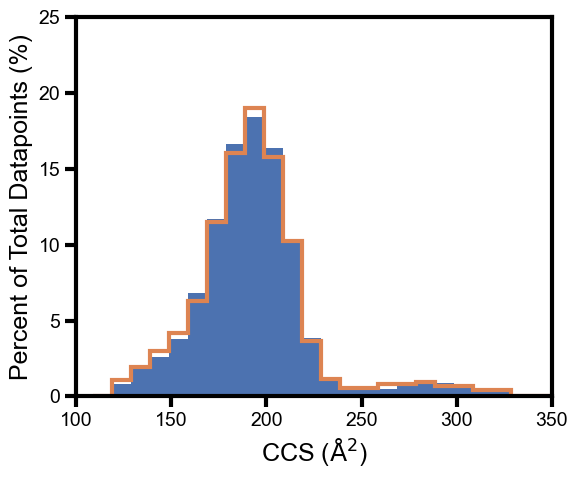

In [16]:
# Column name
COL = "ccs"

ccs_a = train_df[COL].dropna().to_numpy()
ccs_b = test_df[COL].dropna().to_numpy()

# Shared 10 Å^2 bins spanning both datasets
bin_width = 10
lo = min(ccs_a.min(), ccs_b.min())
hi = max(ccs_a.max(), ccs_b.max())
bins = np.arange(lo, hi + bin_width, bin_width)

# Percent weights (each histogram sums to 100%)
w_a = np.ones_like(ccs_a) / len(ccs_a) * 100
w_b = np.ones_like(ccs_b) / len(ccs_b) * 100

fig, ax = plt.subplots(figsize=(6, 5))


ax.hist(
    ccs_a,
    bins=bins,
    weights=w_a,
    color="#4C72B0",
    # alpha=0.7,
    rwidth=1.0,
    edgecolor="none",
    label="train_data"
) 
ax.hist(
    ccs_b,
    bins=bins,
    weights=w_b,
    histtype="step",
    linewidth=3.0,
    color="#DD8452",
    label="training"
)

ax.set_xlabel("CCS ($\mathrm{\AA^2}$)")
ax.set_ylabel("Percent of Total Datapoints (%)")
ax.set_xlim(100, 350)
ax.set_ylim(0, 25)

# ax.legend(frameon=False)
plt.tight_layout()

plt.savefig(
    "Train_Test_Histogram.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

# Training and Test Set PCA

In [8]:
import sys, os
sys.path.append(os.path.abspath("../.."))

from utils import (
    featurize_ccs_dataset,
    load_or_build_fingerprint_vocabulary,
    build_fingerprint_vocabulary,
    build_fingerprint_index,
    build_feature_matrix_sparse,
)

DATABASE_FILE = "../../CCSMLDatabase.db"
FP_VOCAB_FILE = "../../ccsbase2_fp_vocab.joblib"

# adducts with >= 50 occurrences across train + test -- matches the adduct
# vocabulary used when training the production XGBoostRegressor
combined_adduct_counts = pd.concat([train_df["adduct"], test_df["adduct"]]).value_counts()
adducts = sorted(combined_adduct_counts[combined_adduct_counts >= 50].index.tolist())

fp_vocab = load_or_build_fingerprint_vocabulary(DATABASE_FILE, FP_VOCAB_FILE)
fp_index = build_fingerprint_index(fp_vocab)

# same base descriptors (molecular weight, adduct mass, adduct one-hot) + sparse
# Morgan fingerprint columns fed to the XGBoostRegressor -- this can take a
# few minutes since every molecule's fingerprint is recomputed with rdkit
base_features_train, fp_dicts_train, _, metadata_train = featurize_ccs_dataset(train_df, adducts)
base_features_test, fp_dicts_test, _, metadata_test = featurize_ccs_dataset(test_df, adducts)

# subclass per row, aligned to the feature matrices via the metadata returned
# by featurize_ccs_dataset (not train_df/test_df directly) -- reused below for
# coloring the PCA/UMAP plots
subclass_train = np.array([m[1] for m in metadata_train])
subclass_test = np.array([m[1] for m in metadata_test])

X_train_full = build_feature_matrix_sparse(base_features_train, fp_dicts_train, fp_index)
X_test_full = build_feature_matrix_sparse(base_features_test, fp_dicts_test, fp_index)

print(f"Full XGBoost feature set: {X_train_full.shape[1]} columns")
print(f"Train: {X_train_full.shape[0]} rows | Test: {X_test_full.shape[0]} rows")

# The production vocabulary (fp_vocab above) includes every fragment seen in as
# few as ONE molecule (min_molecule_count=1 when it was built). That's fine for
# XGBoost, which is scale-invariant, but it's poison for scaled PCA: a fragment
# seen in 1 of 53k molecules has a std of ~0.004, so standardizing divides that
# molecule's value by a near-zero number and blows it out to a huge outlier --
# which is exactly the "everything collapsed near 0 except a few points near
# 1000" pattern in the plots below. Prune to fragments seen in >= 40 training
# molecules (same threshold used in analysis/reviews/pca_umap_breakdown.ipynb)
# for the PCA/UMAP views only -- the XGBoostRegressor itself still trains on
# the full, unpruned vocabulary.
fp_vocab_pca = build_fingerprint_vocabulary(fp_dicts_train, min_molecule_count=40)
fp_index_pca = build_fingerprint_index(fp_vocab_pca)

X_train_pca = build_feature_matrix_sparse(base_features_train, fp_dicts_train, fp_index_pca)
X_test_pca = build_feature_matrix_sparse(base_features_test, fp_dicts_test, fp_index_pca)

print(f"PCA/UMAP feature set (fingerprints pruned to >= 40 train molecules): {X_train_pca.shape[1]} columns")


def plot_embedding(Z_train, Z_test, subclass_train, subclass_test, palette, xlabel, ylabel, file_prefix, point_size=12):
    """Scatter Z_train/Z_test (2D embeddings) colored by `palette` (subclass -> color),
    with any subclass not in the palette (incl. null) drawn in black behind it.
    No legend -- the palette mapping is printed separately. One shared, square
    axis range across both splits so train/test are directly comparable."""
    combined_min = min(Z_train.min(), Z_test.min())
    combined_max = max(Z_train.max(), Z_test.max())
    pad = 0.05 * (combined_max - combined_min)
    lo, hi = combined_min - pad, combined_max + pad

    for Z, subclasses, split_name in [(Z_train, subclass_train, "train"), (Z_test, subclass_test, "test")]:
        subclasses = np.asarray(subclasses)
        is_top10 = np.isin(subclasses, list(palette.keys()))

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(
            Z[~is_top10, 0], Z[~is_top10, 1],
            color="black", s=point_size, alpha=0.15, edgecolors="none", zorder=1,
        )
        ax.scatter(
            Z[is_top10, 0], Z[is_top10, 1],
            color=[palette[sc] for sc in subclasses[is_top10]], s=point_size, alpha=0.85, edgecolors="none", zorder=2,
        )
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")

        # force identical tick marks on both axes -- matplotlib's default locator
        # picks ticks per-axis based on rendered label space, so it can pick a
        # different count/spacing for x vs y even when xlim/ylim are numerically
        # identical. Pin both axes to the same tick array to guarantee they match.
        shared_ticks = ax.get_xticks()
        shared_ticks = shared_ticks[(shared_ticks >= lo) & (shared_ticks <= hi)]
        ax.set_xticks(shared_ticks)
        ax.set_yticks(shared_ticks)

        plt.tight_layout()
        fig.savefig(f"{file_prefix}_{split_name}.png", dpi=300, bbox_inches="tight")
        plt.show()

Full XGBoost feature set: 39294 columns
Train: 53351 rows | Test: 12802 rows
PCA/UMAP feature set (fingerprints pruned to >= 40 train molecules): 4725 columns


## Subclass Color Palette (Top 20)

In [9]:
import matplotlib.colors as mcolors

top20_subclasses_combined = (
    pd.concat([train_df["subclass"], test_df["subclass"]])
    .dropna()
    .value_counts()
    .head(20)
    .index
    .tolist()
)

cmap = plt.cm.tab20
subclass_palette = {sc: mcolors.to_hex(cmap(i)) for i, sc in enumerate(top20_subclasses_combined)}

print("Subclass -> color (top 20 across train + test, null excluded; everything else is black):")
for subclass, color in subclass_palette.items():
    print(f"  {color}  {subclass}")

Subclass -> color (top 20 across train + test, null excluded; everything else is black):
  #1f77b4  Amino acids, peptides, and analogues
  #aec7e8  Benzoic acids and derivatives
  #ff7f0e  Anilides
  #ffbb78  Benzenesulfonamides
  #2ca02c  Biphenyls and derivatives
  #98df8a  Piperazines
  #d62728  Triazoles
  #ff9896  Carbonyl compounds
  #9467bd  Pyrazoles
  #c5b0d5  Aryl thioethers
  #8c564b  Benzodiazines
  #c49c94  Phenylpyrrolidines
  #e377c2  Tetrazoles
  #f7b6d2  Carbohydrates and carbohydrate conjugates
  #7f7f7f  Diphenylmethanes
  #c7c7c7  Triradylcglycerols
  #bcbd22  Glycerophosphocholines
  #dbdb8d  Glycerophosphoethanolamines
  #17becf  Purines and purine derivatives
  #9edae5  Imidazolidines


/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: divide by zero encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: overflow encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: invalid value encountered in matmul
  matvec=lambda x: X @ x - offset @ x,


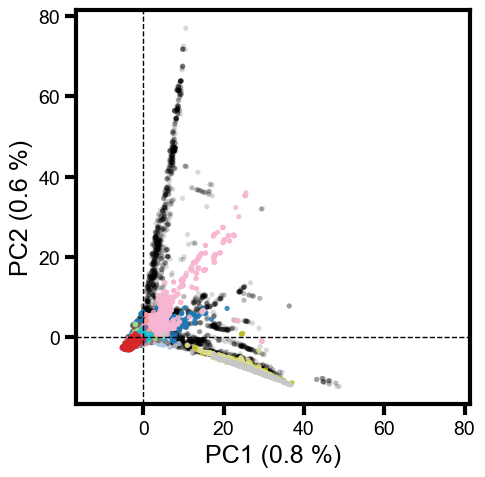

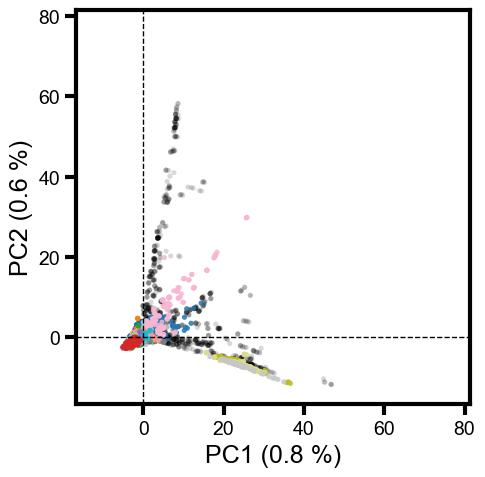

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_sparse = StandardScaler(with_mean=False).fit(X_train_pca)
X_train_sparse_scaled = scaler_sparse.transform(X_train_pca)
X_test_sparse_scaled = scaler_sparse.transform(X_test_pca)

pca_sparse = PCA(n_components=2, svd_solver="arpack", random_state=26).fit(X_train_sparse_scaled)
Z_train_sparse = pca_sparse.transform(X_train_sparse_scaled)
Z_test_sparse = pca_sparse.transform(X_test_sparse_scaled)

var1 = pca_sparse.explained_variance_ratio_[0] * 100
var2 = pca_sparse.explained_variance_ratio_[1] * 100

plot_embedding(
    Z_train_sparse, Z_test_sparse,
    subclass_train, subclass_test, subclass_palette,
    xlabel=f"PC1 ({var1:.1f} %)", ylabel=f"PC2 ({var2:.1f} %)",
    file_prefix="PCA_sparse_scaled", point_size=14,
)

# Training and Test Set UMAP

UMAP hybrid input: 4725 columns (Scaled Base + Unscaled Sparse FPs)


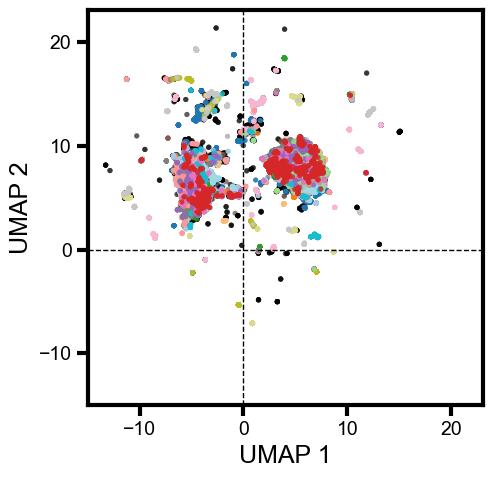

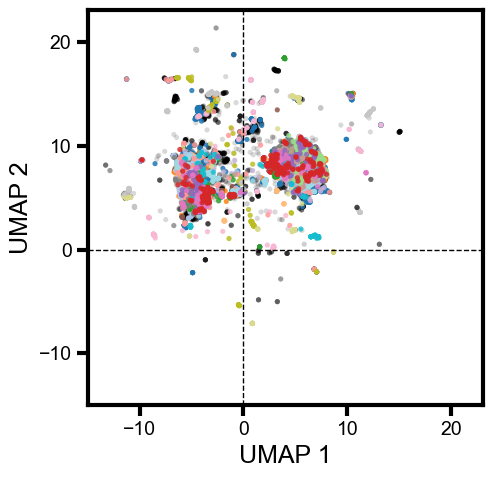

In [11]:
import umap
import scipy.sparse as sp
import numpy as np
from utils import vectorize_fingerprints_sparse
from sklearn.preprocessing import StandardScaler

# 1. Convert base features to dense numpy arrays
base_train_arr = np.array(base_features_train, dtype=np.float32)
base_test_arr = np.array(base_features_test, dtype=np.float32)

# 2. Scale ONLY the base features 
# This prevents molecular weight/mass from dominating the distance calculations
scaler = StandardScaler()
base_train_scaled = scaler.fit_transform(base_train_arr)
base_test_scaled = scaler.transform(base_test_arr)

# 3. Vectorize the sparse fingerprints directly (no scaling, no PCA)
fps_train_sparse = vectorize_fingerprints_sparse(fp_dicts_train, fp_index_pca)
fps_test_sparse = vectorize_fingerprints_sparse(fp_dicts_test, fp_index_pca)

# 4. Horizontally stack the scaled base features with the unscaled sparse fingerprints
X_train_hybrid = sp.hstack([base_train_scaled, fps_train_sparse], format="csr")
X_test_hybrid = sp.hstack([base_test_scaled, fps_test_sparse], format="csr")

print(f"UMAP hybrid input: {X_train_hybrid.shape[1]} columns (Scaled Base + Unscaled Sparse FPs)")

# 5. Run UMAP directly on the hybrid sparse matrix
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.0001,
    metric="cosine",  # Cosine handles the mix of scaled continuous and count data well
)

U_train = reducer.fit_transform(X_train_hybrid)
U_test = reducer.transform(X_test_hybrid)

# 6. Plot
plot_embedding(
    U_train, U_test,
    subclass_train, subclass_test, subclass_palette,
    xlabel="UMAP 1", ylabel="UMAP 2",
    file_prefix="UMAP_hybrid_cosine", point_size=14,
)